# 06 · Pronosticar respetando el tiempo

**RA2 · modelos de series de tiempo, suavizamiento y ARIMA.** Una sesión para referencias y evaluación, otra para interpretación del modelo.

**Caso:** ComercioSur, datos simulados. Ejecutar en orden con kernel activo. Cada ejercicio exige una interpretación y un límite; consultar [manual](../material_propio/EBA_manual_cientifico.html) y [guía](../guia_maestra_eba.html). El curso presupone manejo elemental de tablas de Fundamentos. No instalar paquetes desde las celdas.

### Antes de ejecutar

Núcleo · 150 min guiados + 60 min autónomos orientativos.

**Objetivo:** Comparar pronósticos con igual horizonte y orden temporal preservado.

**Preparación:** Módulos 01–04; tendencia, estacionalidad y error de predicción.

**Ejemplo de referencia:** ComercioSur: 36 meses iniciales, orígenes 36/42/48 y 12 meses finales reservados.

**Práctica:** Comparar una referencia estacional con SES, Holt y ARIMA sin seleccionar con prueba.

**Criterio de logro:** Dibujar las ventanas y explicar métrica, referencia y dependencia entre errores solapados.

**Distribución orientativa:** explicación 40 min; práctica guiada 110 min; trabajo autónomo 60 min. Ajustar tras una clase piloto.

[Guía y secuencia](../guia_maestra_eba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/EBA_manual_cientifico.html#sec-series)

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, Markdown

RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "_transversal/datos").is_dir())
sys.path.insert(0, str(RAIZ / "02_Estadistica_Business_Analytics/reproducibilidad"))
from eba_recursos import *

df = pedidos()
plt.rcParams.update(
    {"figure.figsize": (7, 3.4), "axes.spines.top": False, "axes.spines.right": False}
)

### Dibuja el calendario antes de ajustar

Marca meses 1–36 para el inicio del desarrollo, orígenes 36/42/48 con horizonte común de 12 meses
y meses 61–72 como prueba final. Tres orígenes son una demostración pequeña: sus ventanas se solapan.
Primero calcula la referencia, después compara métodos en selección y finalmente abre la prueba congelada.
Explica qué información se conoce en cada fecha y qué parte de la precisión no puedes estimar con tan poca historia.

<a id="serie"></a>
## Índice temporal y componentes

72 meses independientes del archivo de pedidos. Separar tendencia, estacionalidad anual y ruido. Meses vecinos no son observaciones intercambiables. Diferenciar para estabilizar nivel no garantiza estacionariedad; examine gráfico y ACF.

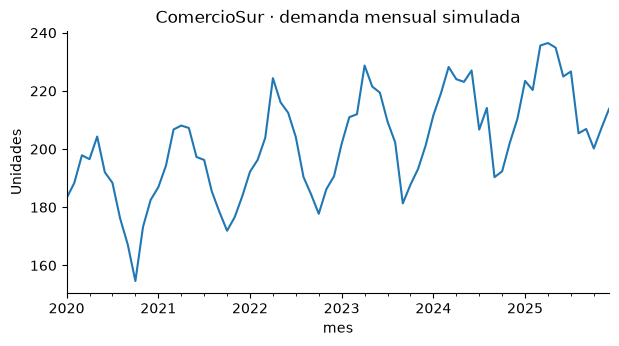

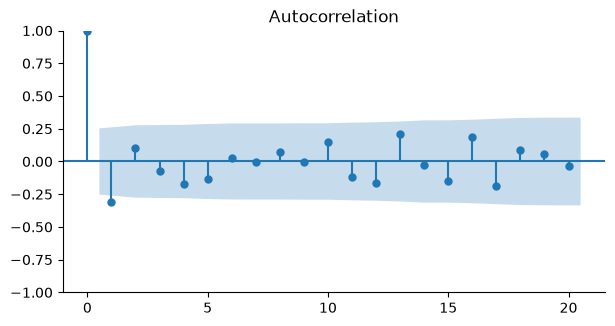

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from statsmodels.graphics.tsaplots import plot_acf

y = serie()
assert len(y) == 72 and not y.isna().any()
y.plot(ylabel="Unidades", title="ComercioSur · demanda mensual simulada")
plt.show()
plot_acf(y.diff(12).dropna(), lags=20)
plt.show()

<a id="particion"></a>
## Diseño de validación temporal

Primeros 36 meses para desarrollo; los siguientes 24 para validación de origen móvil a horizonte 12; los últimos 12 quedan sellados hasta elegir modelo. Se usan tres orígenes (36, 42 y 48 meses observados), cada uno con 12 predicciones. Los errores de ventanas superpuestas son dependientes; no se tratan como 36 réplicas independientes.

In [3]:
desarrollo = y.iloc[:36]
validacion = y.iloc[36:60]
prueba = y.iloc[60:]
display(
    pd.DataFrame(
        {
            "bloque": ["desarrollo", "validacion", "prueba"],
            "desde": [x.index.min() for x in [desarrollo, validacion, prueba]],
            "hasta": [x.index.max() for x in [desarrollo, validacion, prueba]],
            "n": [len(x) for x in [desarrollo, validacion, prueba]],
        }
    )
)

,bloque,desde,hasta,n
0,desarrollo,2020-01-01,2022-12-01,36
1,validacion,2023-01-01,2024-12-01,24
2,prueba,2025-01-01,2025-12-01,12


<a id="modelos"></a>
## Referencias, suavizamiento y ARIMA

SES actualiza nivel: l_t=αy_t+(1−α)l_(t−1); Holt agrega tendencia. ARIMA(1,1,0) modela dependencia de diferencias: Δy_t=φΔy_(t−1)+ε_t, sin tendencia determinista en este ajuste. Este ARIMA sencillo no incluye estacionalidad; el ingenuo estacional es una referencia exigente.

In [4]:
def pronosticos(train, h):
    return {
        "Ingenuo": np.repeat(train.iloc[-1], h),
        "Estacional": np.resize(train.iloc[-12:].to_numpy(), h),
        "Media movil 3": np.repeat(train.iloc[-3:].mean(), h),
        "SES": np.asarray(
            SimpleExpSmoothing(train, initialization_method="estimated").fit().forecast(h)
        ),
        "Holt": np.asarray(Holt(train, initialization_method="estimated").fit().forecast(h)),
        "ARIMA(1,1,0)": np.asarray(ARIMA(train, order=(1, 1, 0), trend="n").fit().forecast(h)),
    }


print(
    "Primer pronóstico de cada método:",
    {k: float(v[0]) for k, v in pronosticos(desarrollo, 1).items()},
)

Primer pronóstico de cada método: {'Ingenuo': 190.68, 'Estacional': 192.22, 'Media movil 3': 184.88666666666668, 'SES': 190.67999993383884, 'Holt': 190.89571580035678, 'ARIMA(1,1,0)': 192.07611315522678}


<a id="validacion"></a>
## Evaluación con origen móvil

Cada ajuste ve solo el pasado del origen. MAE y RMSE conservan unidades. MASE usa como escala el MAE ingenuo estacional calculado exclusivamente en el entrenamiento de cada origen; se informa la media de errores escalados. Evite MAPE si existen ceros.

In [5]:
reg = []
for origen in [36, 42, 48]:
    train = y.iloc[:origen]
    escala = np.abs(train.to_numpy()[12:] - train.to_numpy()[:-12]).mean()
    for nombre, pred in pronosticos(train, 12).items():
        errores = y.iloc[origen : origen + 12].to_numpy() - pred
        for horizonte, error in enumerate(errores, 1):
            reg.append(
                {
                    "modelo": nombre,
                    "origen": origen,
                    "horizonte": horizonte,
                    "error": error,
                    "absoluto": abs(error),
                    "cuadrado": error**2,
                    "escalado": abs(error) / escala,
                }
            )
val = (
    pd.DataFrame(reg)
    .groupby("modelo")
    .agg(MAE=("absoluto", "mean"), MSE=("cuadrado", "mean"), MASE=("escalado", "mean"))
)
val["RMSE"] = np.sqrt(val.pop("MSE"))
display(val.sort_values("MAE"))
elegido = val.MAE.idxmin()
print("Modelo elegido sin prueba:", elegido)

,MAE,MASE,RMSE
modelo,,,
Estacional,7.991389,1.049144,8.797803
"ARIMA(1,1,0)",14.357041,1.886370,17.263489
Ingenuo,15.373611,2.019822,18.476959
SES,15.373611,2.019822,18.476959
Holt,15.487730,2.034418,18.784347
Media movil 3,18.855833,2.477167,22.654768


Modelo elegido sin prueba: Estacional


<a id="prueba"></a>
## Una evaluación final y sus límites

Se reestima con 60 meses y se genera el horizonte completo antes de mirar sus errores. No cambiar el ganador tras observar esta tabla. La selección y la prueba usan el mismo horizonte anual. Solo hay tres orígenes parcialmente superpuestos; ampliar la historia permitirá evaluar estabilidad por origen y horizonte.

MAE: 9.015833333333333 RMSE: 10.57691235663792 MASE: 1.1640530435484302


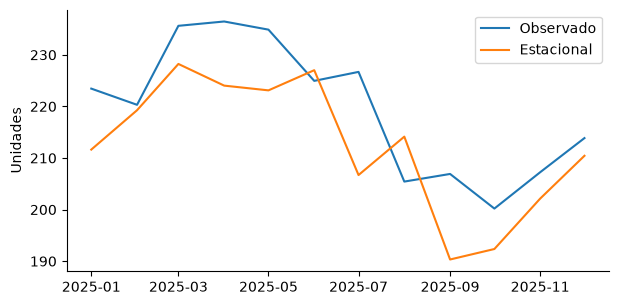

In [6]:
train = y.iloc[:60]
pred = pronosticos(train, 12)[elegido]
escala = np.abs(train.to_numpy()[12:] - train.to_numpy()[:-12]).mean()
error = prueba.to_numpy() - pred
print(
    "MAE:",
    np.abs(error).mean(),
    "RMSE:",
    np.sqrt(np.mean(error**2)),
    "MASE:",
    np.abs(error).mean() / escala,
)
plt.plot(prueba.index, prueba, label="Observado")
plt.plot(prueba.index, pred, label=elegido)
plt.ylabel("Unidades")
plt.legend()
plt.show()

<a id="intervalos"></a>
## Intervalos ARIMA y diagnóstico

Ejercicio metodológico separado del ganador: intervalos gaussianos del ARIMA prefijado, condicionados al modelo y parámetros estimados. No incluyen toda la incertidumbre de selección ni un cambio de régimen. La cobertura de 12 meses es muy imprecisa y dependiente.

,pronostico,li,ls,observado
2025-01-01,211.918168,193.119823,230.716513,223.45
2025-02-01,212.184993,183.118944,241.251041,220.31
2025-03-01,212.232834,175.307883,249.157784,235.62
2025-04-01,212.241412,168.801619,255.681204,236.46
2025-05-01,212.242950,163.136243,261.349656,234.88
2025-06-01,212.243225,158.057607,266.428844,224.95
2025-07-01,212.243275,153.415369,271.071180,226.69
2025-08-01,212.243284,149.113506,275.373061,205.43
2025-09-01,212.243285,145.086632,279.399939,206.91
2025-10-01,212.243286,141.287923,283.198648,200.20


Convergencia: True
Cobertura descriptiva: 1.0


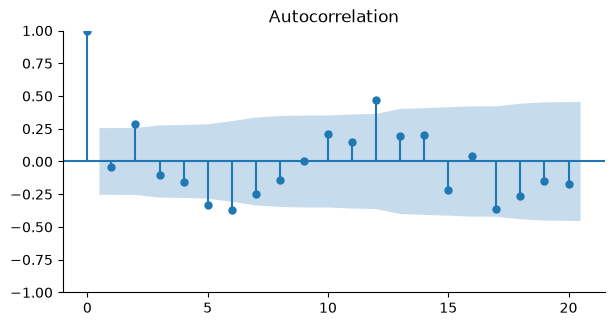

In [7]:
ar = ARIMA(train, order=(1, 1, 0), trend="n").fit()
f = ar.get_forecast(12)
ci = f.conf_int(alpha=0.05)
display(
    pd.DataFrame(
        {
            "pronostico": f.predicted_mean,
            "li": ci.iloc[:, 0],
            "ls": ci.iloc[:, 1],
            "observado": prueba,
        }
    )
)
print("Convergencia:", ar.mle_retvals.get("converged"))
assert ar.mle_retvals.get("converged")
print("Cobertura descriptiva:", ((prueba >= ci.iloc[:, 0]) & (prueba <= ci.iloc[:, 1])).mean())
plot_acf(ar.resid.iloc[1:], lags=20)
plt.show()

<a id="suavizamiento"></a>
## Actividad interactiva

Mover α muestra reacción frente a ruido; no reoptimice usando la prueba. Explique qué información pierde SES ante tendencia y estacionalidad y por qué un modelo más complejo puede perder contra una referencia sencilla.

In [8]:
@widgets.interact(alpha=widgets.FloatSlider(value=0.3, min=0.05, max=0.95, step=0.05))
def suavizar(alpha):
    m = SimpleExpSmoothing(desarrollo, initialization_method="estimated").fit(
        smoothing_level=alpha, optimized=False
    )
    plt.plot(desarrollo, label="Datos desarrollo")
    plt.plot(m.fittedvalues, label=f"SES alfa={alpha:.2f}")
    plt.ylabel("Unidades")
    plt.legend()
    plt.show()

interactive(children=(FloatSlider(value=0.3, description='alpha', max=0.95, min=0.05, step=0.05), Output()), _…

## Comprobación y entrega

Responda la autoevaluación y complete la actividad del último bloque. Entregue objetivo, método, supuesto, resultado con unidades y decisión condicionada. Las soluciones orientadoras permiten estudiar, pero no sustituyen su interpretación.

In [9]:
auto_06 = pregunta(
    "¿Se puede mezclar meses al azar para medir un pronóstico futuro?",
    "Sí, aumenta el tamaño del entrenamiento",
    "No, la evaluación debe respetar la información disponible en cada fecha",
    "Una partición aleatoria puede filtrar información del futuro y medir otra tarea.",
    tercera="Sí, si se estratifica por el nombre del mes",
)
display(auto_06)

## Práctica de transferencia 06

Para reales [120,150,180], una referencia predice [110,160,170] y otro método [125,140,190]. Calcula MAE. Dibuja entrenamiento, selección y prueba por fechas para un horizonte de tres meses; explica cuándo se conoce cada error.

**Entrega:** hipótesis previa, cálculo con unidades, interpretación y límite. Completa tu respuesta antes de consultar la [pauta docente](../material_propio/PAUTA_DOCENTE.md#nb06).

**Discusión:** ¿Es válido tratar errores de orígenes solapados como independientes?

### Tu resolución

Edita esta celda: escribe tu hipótesis, procedimiento, resultado, interpretación y una comprobación. Adjunta tu código o gráfico si la actividad lo requiere.

**Auto-revisión:** ¿usé la población correcta?, ¿declaré unidades y supuestos?, ¿mi evidencia permite esa conclusión?